# Airbnb Market Intelligence

# 06 - Outlier Analysis

## Objectives

- Detect outliers in key numerical variables
- Understand their impact
- Identify unusually expensive or large listings

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [2]:
df = pd.read_csv("../data/cleaned/listings_cleaned.csv")

print(df.shape)

df.head()

(279712, 32)


,listing_id,name,host_id,host_since,host_location,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_total_listings_count,...,minimum_nights,maximum_nights,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable
0,281420,"Beautiful Flat in le Village Montmartre, Paris",1466919,2011-12-03,"Paris, Ile-de-France, France",Unknown,1.0,0.98,f,1.0,...,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
1,3705183,39 mÃÂ² Paris (Sacre CÃ âur),10328771,2013-11-29,"Paris, Ile-de-France, France",Unknown,1.0,0.98,f,1.0,...,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
2,4082273,"Lovely apartment with Terrace, 60m2",19252768,2014-07-31,"Paris, Ile-de-France, France",Unknown,1.0,0.98,f,1.0,...,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
3,4797344,Cosy studio (close to Eiffel tower),10668311,2013-12-17,"Paris, Ile-de-France, France",Unknown,1.0,0.98,f,1.0,...,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
4,4823489,Close to Eiffel Tower - Beautiful flat : 2 rooms,24837558,2014-12-14,"Paris, Ile-de-France, France",Unknown,1.0,0.98,f,1.0,...,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f


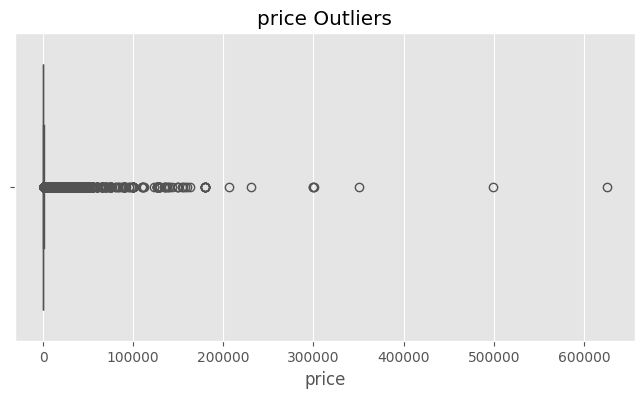

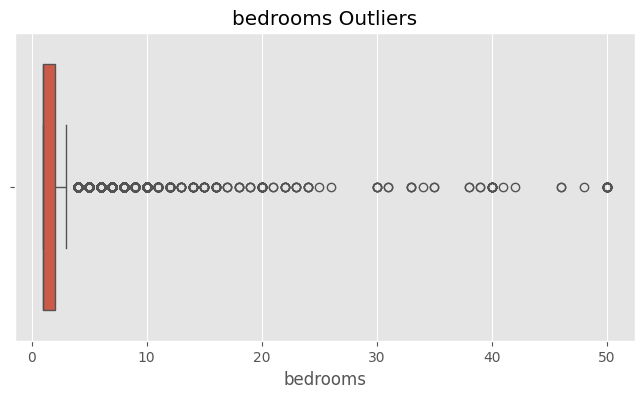

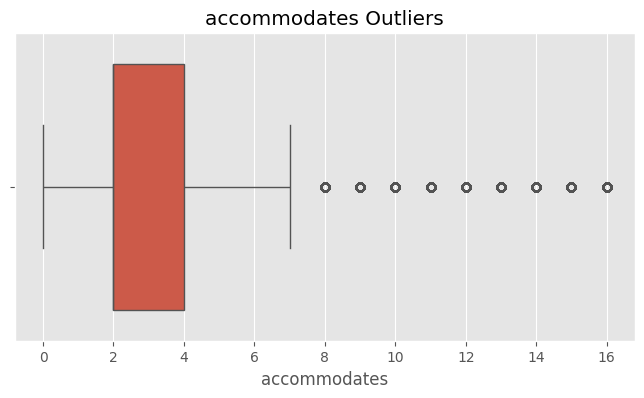

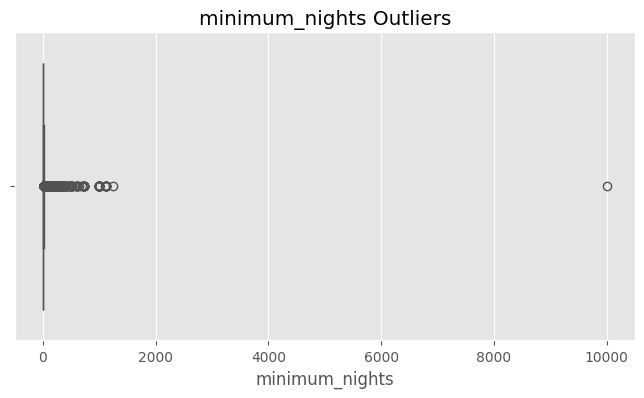

In [3]:
cols = [
    "price",
    "bedrooms",
    "accommodates",
    "minimum_nights"
]

for col in cols:

    plt.figure(figsize=(8,4))

    sns.boxplot(x=df[col])

    plt.title(f"{col} Outliers")

    plt.show()

In [4]:
Q1 = df["price"].quantile(0.25)
Q3 = df["price"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[
    (df["price"] < lower) |
    (df["price"] > upper)
]

print("Price Outliers:", len(outliers))

outliers.head()

Price Outliers: 31395


,listing_id,name,host_id,host_since,host_location,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_total_listings_count,...,minimum_nights,maximum_nights,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable
3423,9179633,Charming flat near Champs Elysees,8261156,2013-08-19,"Paris, Ile-de-France, France",Unknown,1.0,0.98,f,1.0,...,1,1125,89.0,9.0,9.0,9.0,9.0,10.0,9.0,f
7883,19782423,2 bedrooms Appt-Near Champs Elysees,21125647,2014-09-09,"Paris, Ile-de-France, France",Unknown,1.0,0.98,f,1.0,...,3,1125,96.0,10.0,10.0,10.0,10.0,10.0,10.0,t
8549,7225849,"Artistic apartment, Montmartre",34063120,2015-05-23,"Paris, Ile-de-France, France",Unknown,1.0,0.98,f,1.0,...,2,1125,97.0,10.0,10.0,10.0,10.0,9.0,10.0,f
9165,5998400,Loft 160 m2 Canal St Martin,31141046,2015-04-13,"Paris, Ile-de-France, France",Unknown,1.0,0.98,f,1.0,...,5,1125,96.0,10.0,10.0,10.0,10.0,10.0,10.0,f
9244,37102870,SeaSide Hong Kong,107359991,2016-12-15,"Paris, Ile-de-France, France",Unknown,1.0,1.00,f,1.0,...,1,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f


In [5]:
top_price = (
    df[["listing_id","city","property_type","price"]]
    .sort_values("price", ascending=False)
    .head(10)
)

top_price

,listing_id,city,property_type,price
181027,13879989,Rio de Janeiro,Shared room in house,625216
162251,47885441,Mexico City,Room in boutique hotel,499000
98808,23895520,Mexico City,Private room in house,350000
135705,3410763,Bangkok,Private room in apartment,300177
218597,12056763,Bangkok,Entire house,300000
182185,13033135,Bangkok,Private room in house,300000
44906,29970931,Bangkok,Entire apartment,231047
196424,38733276,Mexico City,Private room in apartment,206499
97609,41578696,Bangkok,Entire villa,180124
208690,41615363,Mexico City,Entire house,180000


In [6]:
largest = (
    df[["listing_id","city","bedrooms","accommodates","price"]]
    .sort_values(
        ["bedrooms","accommodates"],
        ascending=False
    )
    .head(10)
)

largest

,listing_id,city,bedrooms,accommodates,price
44226,16037944,Mexico City,50.0,16,3614
91807,20118571,Istanbul,50.0,16,214
92133,6810808,Mexico City,50.0,16,1832
96619,17777234,Mexico City,50.0,16,1858
97294,45514646,Istanbul,50.0,16,120
97365,39293623,Cape Town,50.0,16,3000
97667,43711025,Istanbul,50.0,16,280
98314,45221762,Istanbul,50.0,16,297
202737,18766792,Paris,50.0,16,48
202792,8876983,Paris,50.0,16,51


In [7]:
percentage = (
    len(outliers) / len(df)
) * 100

print(f"Price Outlier Percentage: {percentage:.2f}%")

Price Outlier Percentage: 11.22%


# Business Insights

- A small percentage of listings are price outliers.
- Luxury properties contribute significantly to the upper price range.
- Most listings fall within a reasonable price range.
- Outliers should be reviewed before training predictive models.
- Extreme listings may represent luxury homes or data entry issues.